# 🎯 Fake Review Detection - Complete ML Pipeline

## 📚 Step-by-Step Guide for Beginners

### **Machine Learning Workflow:**
1. **Dataset Find** ✅ - Tumne already `fake_reviews_dataset.csv` download kar liya
2. **Data Load** - Pandas se CSV file ko load karenge
3. **Data Exploration** - Data ko samajhenge (categories, labels, distribution)
4. **Data Preprocessing** - Text cleaning (special characters remove, lowercase, stemming)
5. **Train-Test Split** - Data ko 2 parts me divide (80% training, 20% testing)
6. **Feature Extraction** - Text ko numbers me convert (TF-IDF)
7. **Model Training** - Different algorithms train karenge
8. **Model Evaluation** - Accuracy, Precision, Recall check karenge
9. **Save Models** - Best models ko save karenge

### **Why Train-Test Split?**
- **Training Data (80%)**: Model ko sikhane ke liye
- **Testing Data (20%)**: Model ki performance check karne ke liye (unseen data)
- Agar same data pe train aur test karenge, toh model "ratta maar" lega (overfitting)

---

## Step 1: Import Libraries 📦
Sabse pehle required libraries import karenge

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Text preprocessing
import re
from nltk.stem import PorterStemmer

# ML models and tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB, BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Saving models
import pickle
import os
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Load Dataset 📁
CSV file ko pandas DataFrame me load karenge

In [2]:
# Dataset ka path
dataset_path = 'fake_reviews_dataset.csv'

# CSV file load karo
print(f"📂 Loading dataset from: {dataset_path}")
df = pd.read_csv(dataset_path)

print(f"✅ Dataset loaded successfully!")
print(f"📊 Total records: {len(df):,}")
print(f"📋 Columns: {list(df.columns)}")
print("\n👀 First 5 rows:")
df.head()

📂 Loading dataset from: fake_reviews_dataset.csv
✅ Dataset loaded successfully!
📊 Total records: 40,432
📋 Columns: ['category', 'rating', 'label', 'text_']

👀 First 5 rows:


,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...


## Step 3: Data Exploration 🔍
Data ko detail me samajhte hain

In [3]:
# Basic info
print("📊 Dataset Info:")
print(df.info())
print("\n" + "="*80)

# Missing values check
print("\n❓ Missing Values:")
print(df.isnull().sum())
print("\n" + "="*80)

# Label distribution
print("\n🏷️ Label Distribution:")
print(df['label'].value_counts())
print(f"\nOR (Original Reviews): {(df['label']=='OR').sum():,} ({(df['label']=='OR').sum()/len(df)*100:.2f}%)")
print(f"CG (Computer Generated): {(df['label']=='CG').sum():,} ({(df['label']=='CG').sum()/len(df)*100:.2f}%)")
print("\n" + "="*80)

# Category distribution
print("\n📦 Category Distribution:")
print(df['category'].value_counts())
print("\n" + "="*80)

# Rating distribution
print("\n⭐ Rating Distribution:")
print(df['rating'].value_counts().sort_index())

📊 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40432 entries, 0 to 40431
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  40432 non-null  object 
 1   rating    40432 non-null  float64
 2   label     40432 non-null  object 
 3   text_     40432 non-null  object 
dtypes: float64(1), object(3)
memory usage: 1.2+ MB
None


❓ Missing Values:
category    0
rating      0
label       0
text_       0
dtype: int64


🏷️ Label Distribution:
label
CG    20216
OR    20216
Name: count, dtype: int64

OR (Original Reviews): 20,216 (50.00%)
CG (Computer Generated): 20,216 (50.00%)


📦 Category Distribution:
category
Kindle_Store_5                  4730
Books_5                         4370
Pet_Supplies_5                  4254
Home_and_Kitchen_5              4056
Electronics_5                   3988
Sports_and_Outdoors_5           3946
Tools_and_Home_Improvement_5    3858
Clothing_Shoes_and_Jewelry_5    3848
To

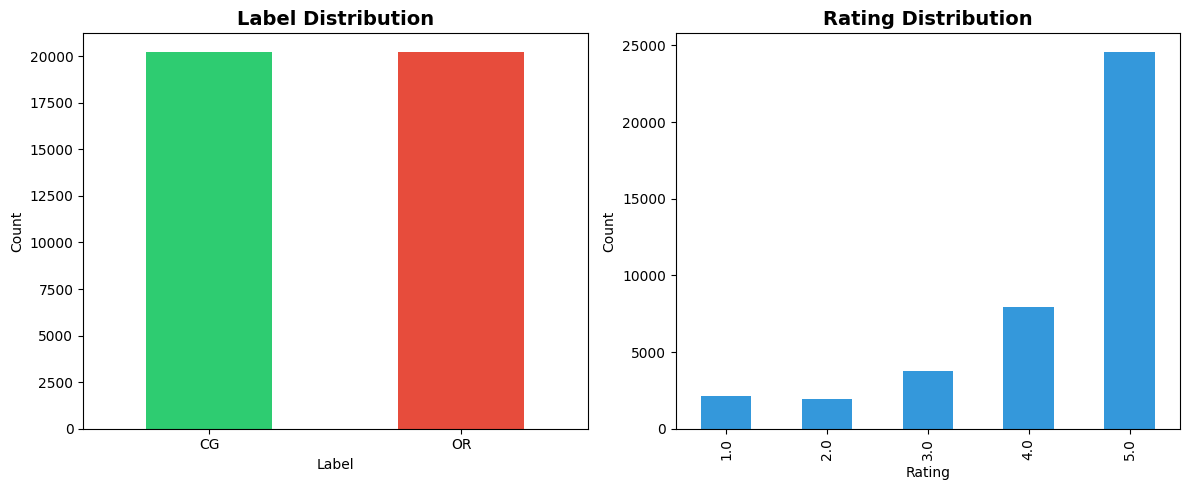

In [4]:
# Visualization - Label Distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['label'].value_counts().plot(kind='bar', color=['#2ecc71', '#e74c3c'])
plt.title('Label Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
df['rating'].value_counts().sort_index().plot(kind='bar', color='#3498db')
plt.title('Rating Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

## Step 4: Data Preprocessing 🧹
Text ko clean karke model ke liye ready karenge

**Preprocessing Steps:**
- URLs remove
- Special characters remove
- Lowercase conversion
- Stemming (words ko root form me convert)

In [5]:
# Stemmer initialize
ps = PorterStemmer()

def clean_text(text) -> str:
    """Text cleaning function"""
    if text is None or pd.isna(text):
        return ""
    
    # Convert to string
    text = str(text)
    
    # Remove URLs
    text = re.sub(r'http\S+', ' ', text)
    
    # Remove special characters, keep only letters
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Lowercase
    text = text.lower()
    
    # Stemming
    words = [ps.stem(word) for word in text.split()]
    
    return " ".join(words)

# Example
sample_text = "Love this!!! Best product EVER!!! http://example.com"
print(f"Original: {sample_text}")
print(f"Cleaned: {clean_text(sample_text)}")

Original: Love this!!! Best product EVER!!! http://example.com
Cleaned: love thi best product ever


In [6]:
# Clean all reviews
print("🧹 Cleaning text data...")
df['cleaned_text'] = df['text_'].apply(clean_text)

# Remove empty reviews
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)

print(f"✅ Text cleaning complete!")
print(f"📊 Records after cleaning: {len(df):,}")
print("\n📝 Sample cleaned reviews:")
for i in range(3):
    print(f"\n{i+1}. Original: {df.iloc[i]['text_'][:100]}...")
    print(f"   Cleaned: {df.iloc[i]['cleaned_text'][:100]}...")

🧹 Cleaning text data...
✅ Text cleaning complete!
📊 Records after cleaning: 40,431

📝 Sample cleaned reviews:

1. Original: Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty...
   Cleaned: love thi well made sturdi and veri comfort i love it veri pretti...

2. Original: love it, a great upgrade from the original.  I've had mine for a couple of years...
   Cleaned: love it a great upgrad from the origin i ve had mine for a coupl of year...

3. Original: This pillow saved my back. I love the look and feel of this pillow....
   Cleaned: thi pillow save my back i love the look and feel of thi pillow...


## Step 5: Prepare Data for Training 🎯
Labels ko numerical format me convert karenge:
- **OR (Original Review) → 1** (Genuine)
- **CG (Computer Generated) → 0** (Fake)

In [7]:
# Convert labels to binary
df['label_numeric'] = df['label'].apply(lambda x: 1 if x == 'OR' else 0)

print("🔢 Label Encoding:")
print("OR (Original) → 1 (Genuine)")
print("CG (Computer Generated) → 0 (Fake)")
print(f"\n✅ Encoding complete!")
print(f"\n📊 Distribution:")
print(df['label_numeric'].value_counts())

🔢 Label Encoding:
OR (Original) → 1 (Genuine)
CG (Computer Generated) → 0 (Fake)

✅ Encoding complete!

📊 Distribution:
label_numeric
1    20216
0    20215
Name: count, dtype: int64


## Step 6: Train-Test Split 🔀

### ❓ Why Train-Test Split?
1. **Training Set (80%)** - Model ko patterns sikhane ke liye
2. **Test Set (20%)** - Model ko unseen data pe evaluate karne ke liye

### 📌 Important:
- Test data model training me use nahi hota
- Ye real-world performance ka indication deta hai
- Overfitting se bachata hai

In [8]:
# Prepare X (features) and y (labels)
X = np.array(df['cleaned_text'])
y = np.array(df['label_numeric'])

# Split: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 20% for testing
    random_state=42,    # For reproducibility
    stratify=y          # Maintain label distribution
)

print("📊 Data Split Summary:")
print("="*60)
print(f"Total records: {len(X):,}")
print(f"\n🎓 Training Set: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"   - Genuine (1): {(y_train==1).sum():,}")
print(f"   - Fake (0): {(y_train==0).sum():,}")
print(f"\n🧪 Testing Set: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print(f"   - Genuine (1): {(y_test==1).sum():,}")
print(f"   - Fake (0): {(y_test==0).sum():,}")
print("="*60)

📊 Data Split Summary:
Total records: 40,431

🎓 Training Set: 32,344 (80.0%)
   - Genuine (1): 16,172
   - Fake (0): 16,172

🧪 Testing Set: 8,087 (20.0%)
   - Genuine (1): 4,044
   - Fake (0): 4,043


## Step 7: Model Training 🚀

Multiple algorithms train karenge aur sabka performance compare karenge.

### 🤖 Models we'll train:
1. **Logistic Regression** - Simple, fast, interpretable
2. **Naive Bayes** (3 variants) - Good for text classification
3. **K-Nearest Neighbors** - Instance-based learning
4. **Support Vector Machine** - Powerful for high-dimensional data
5. **Random Forest** - Ensemble method
6. **Gradient Boosting** - Advanced ensemble
7. **AdaBoost** - Adaptive boosting
8. **Decision Tree** - Baseline model

In [9]:
# Define models
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'MultinomialNB': MultinomialNB(alpha=0.1),
    'ComplementNB': ComplementNB(alpha=0.1),
    'BernoulliNB': BernoulliNB(alpha=0.1),
    'KNeighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'LinearSVC': LinearSVC(max_iter=2000, random_state=42, C=1.0),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=20)
}

print(f"🤖 Total models to train: {len(models)}")
print(f"Models: {', '.join(models.keys())}")

🤖 Total models to train: 10
Models: LogisticRegression, MultinomialNB, ComplementNB, BernoulliNB, KNeighbors, LinearSVC, RandomForest, GradientBoosting, AdaBoost, DecisionTree


In [10]:
# Training and evaluation
results = {}
trained_pipelines = {}

print("🎓 Starting model training...\n")
print("="*80)

for name, model in models.items():
    print(f"\n🔄 Training {name}...")
    
    # Create pipeline: TF-IDF + Model
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
        ('clf', model)
    ])
    
    # Train
    import time
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store results
    results[name] = {
        'accuracy': round(float(accuracy), 4),
        'precision': round(float(precision), 4),
        'recall': round(float(recall), 4),
        'f1_score': round(float(f1), 4),
        'training_time': round(float(training_time), 2)
    }
    
    trained_pipelines[name] = pipeline
    
    print(f"✅ {name} trained in {training_time:.2f}s")
    print(f"   Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

print("\n" + "="*80)
print("✅ All models trained successfully!")

🎓 Starting model training...


🔄 Training LogisticRegression...
✅ LogisticRegression trained in 6.09s
   Accuracy: 0.9269 | Precision: 0.9194 | Recall: 0.9360 | F1: 0.9276

🔄 Training MultinomialNB...
✅ MultinomialNB trained in 6.00s
   Accuracy: 0.8831 | Precision: 0.8778 | Recall: 0.8902 | F1: 0.8840

🔄 Training ComplementNB...
✅ ComplementNB trained in 5.90s
   Accuracy: 0.8831 | Precision: 0.8778 | Recall: 0.8902 | F1: 0.8840

🔄 Training BernoulliNB...
✅ BernoulliNB trained in 5.09s
   Accuracy: 0.8589 | Precision: 0.8787 | Recall: 0.8328 | F1: 0.8551

🔄 Training KNeighbors...
✅ KNeighbors trained in 5.98s
   Accuracy: 0.5023 | Precision: 0.7317 | Recall: 0.0074 | F1: 0.0147

🔄 Training LinearSVC...
✅ LinearSVC trained in 7.12s
   Accuracy: 0.9267 | Precision: 0.9247 | Recall: 0.9290 | F1: 0.9269

🔄 Training RandomForest...
✅ RandomForest trained in 22.80s
   Accuracy: 0.9001 | Precision: 0.8812 | Recall: 0.9248 | F1: 0.9025

🔄 Training GradientBoosting...
✅ GradientBoosting traine

## Step 8: Results Comparison 📊
Sabhi models ka performance compare karte hain

In [11]:
# Create results dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('accuracy', ascending=False)

print("🏆 MODEL PERFORMANCE COMPARISON")
print("="*80)
print(results_df.to_string())
print("="*80)

# Best model
best_model = results_df.index[0]
best_accuracy = results_df.iloc[0]['accuracy']
print(f"\n🥇 Best Model: {best_model} (Accuracy: {best_accuracy:.4f})")

🏆 MODEL PERFORMANCE COMPARISON
                    accuracy  precision  recall  f1_score  training_time
LogisticRegression    0.9269     0.9194  0.9360    0.9276           6.09
LinearSVC             0.9267     0.9247  0.9290    0.9269           7.12
RandomForest          0.9001     0.8812  0.9248    0.9025          22.80
MultinomialNB         0.8831     0.8778  0.8902    0.8840           6.00
ComplementNB          0.8831     0.8778  0.8902    0.8840           5.90
BernoulliNB           0.8589     0.8787  0.8328    0.8551           5.09
GradientBoosting      0.8394     0.8230  0.8647    0.8434          93.25
AdaBoost              0.8081     0.7937  0.8326    0.8127          47.71
DecisionTree          0.7616     0.7299  0.8306    0.7770          17.38
KNeighbors            0.5023     0.7317  0.0074    0.0147           5.98

🥇 Best Model: LogisticRegression (Accuracy: 0.9269)


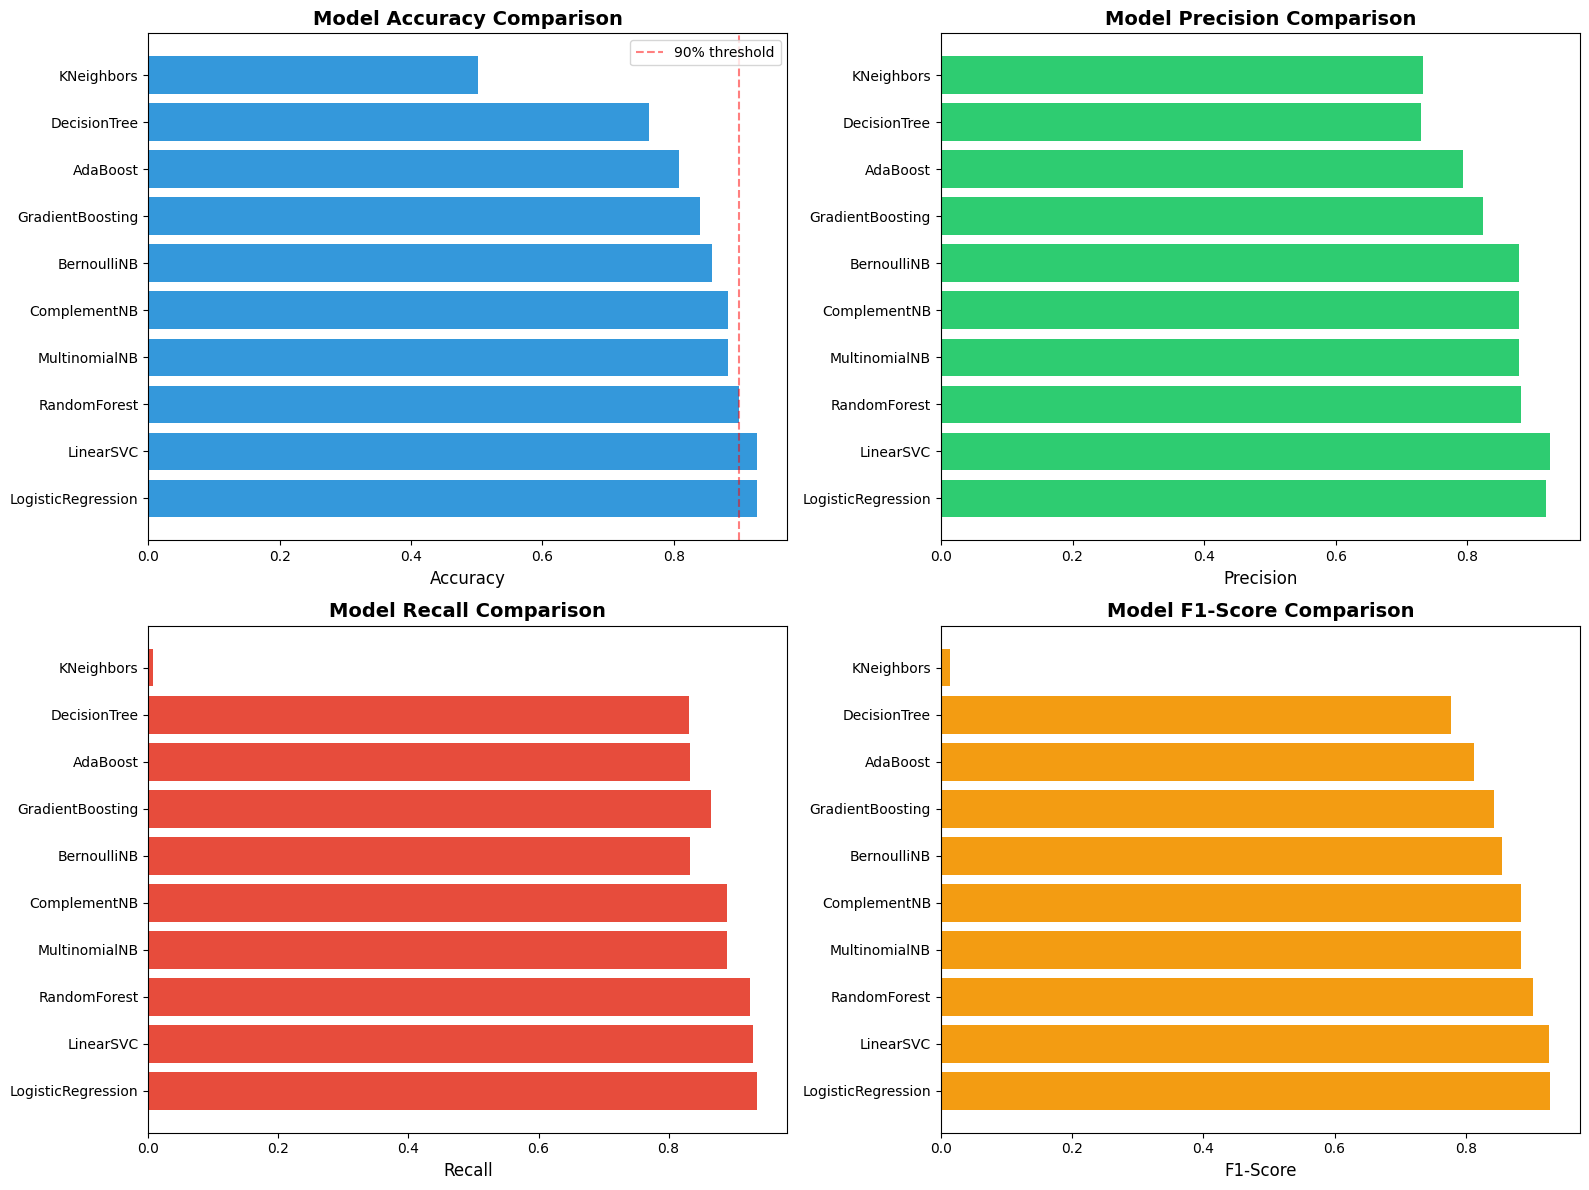

In [12]:
# Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Accuracy comparison
axes[0, 0].barh(results_df.index, results_df['accuracy'], color='#3498db')
axes[0, 0].set_xlabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0, 0].axvline(x=0.9, color='red', linestyle='--', alpha=0.5, label='90% threshold')
axes[0, 0].legend()

# Precision comparison
axes[0, 1].barh(results_df.index, results_df['precision'], color='#2ecc71')
axes[0, 1].set_xlabel('Precision', fontsize=12)
axes[0, 1].set_title('Model Precision Comparison', fontsize=14, fontweight='bold')

# Recall comparison
axes[1, 0].barh(results_df.index, results_df['recall'], color='#e74c3c')
axes[1, 0].set_xlabel('Recall', fontsize=12)
axes[1, 0].set_title('Model Recall Comparison', fontsize=14, fontweight='bold')

# F1-Score comparison
axes[1, 1].barh(results_df.index, results_df['f1_score'], color='#f39c12')
axes[1, 1].set_xlabel('F1-Score', fontsize=12)
axes[1, 1].set_title('Model F1-Score Comparison', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

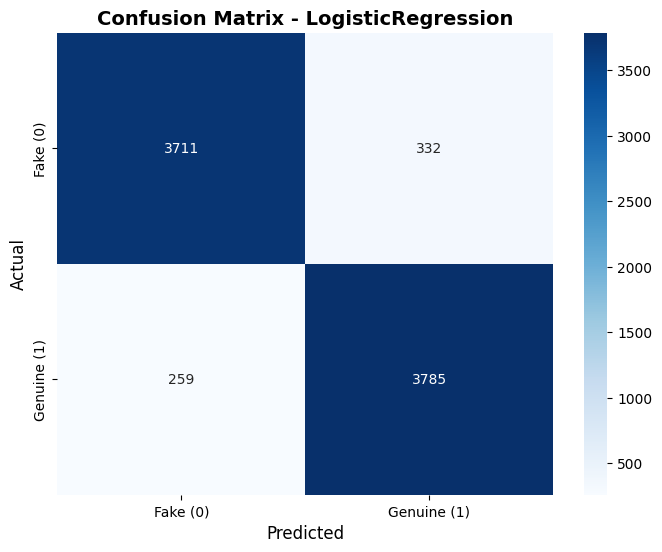


📊 Classification Report - LogisticRegression:
              precision    recall  f1-score   support

        Fake       0.93      0.92      0.93      4043
     Genuine       0.92      0.94      0.93      4044

    accuracy                           0.93      8087
   macro avg       0.93      0.93      0.93      8087
weighted avg       0.93      0.93      0.93      8087



In [13]:
# Confusion Matrix for best model
best_pipeline = trained_pipelines[best_model]
y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Fake (0)', 'Genuine (1)'],
            yticklabels=['Fake (0)', 'Genuine (1)'])
plt.title(f'Confusion Matrix - {best_model}', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.show()

print(f"\n📊 Classification Report - {best_model}:")
print("="*60)
print(classification_report(y_test, y_pred_best, target_names=['Fake', 'Genuine']))

## Step 9: Save Models 💾

Trained models ko `models_40k_pkl` folder me save karenge.
Purani models override nahi hongi!

In [14]:
# Create new directory for 72k models
models_dir = 'models_40k_pkl'
os.makedirs(models_dir, exist_ok=True)

print(f"📁 Saving models to: {models_dir}")
print("="*60)

# Save each model
for name, pipeline in trained_pipelines.items():
    model_path = os.path.join(models_dir, f"{name}.pkl")
    with open(model_path, 'wb') as f:
        pickle.dump(pipeline, f)
    print(f"✅ Saved: {name}.pkl")

# Save metrics summary
metrics_path = os.path.join(models_dir, 'models_summary.pkl')
with open(metrics_path, 'wb') as f:
    pickle.dump(results, f)
print(f"✅ Saved: models_summary.pkl")

# Save as text file also
readme_path = os.path.join(models_dir, 'README_40k.txt')
with open(readme_path, 'w') as f:
    f.write("Fake Review Detection Models - 40K Dataset\n")
    f.write("="*60 + "\n\n")
    f.write(f"Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Total Records: {len(df):,}\n")
    f.write(f"Training Set: {len(X_train):,}\n")
    f.write(f"Test Set: {len(X_test):,}\n\n")
    f.write("Model Performance:\n")
    f.write("-"*60 + "\n")
    f.write(results_df.to_string())
    f.write("\n\n" + "="*60 + "\n")
    f.write(f"Best Model: {best_model} (Accuracy: {best_accuracy:.4f})\n")

print(f"✅ Saved: README_40k.txt")
print("\n" + "="*60)
print("✅ All models saved successfully!")
print(f"📍 Location: {os.path.abspath(models_dir)}")

📁 Saving models to: models_40k_pkl
✅ Saved: LogisticRegression.pkl
✅ Saved: MultinomialNB.pkl
✅ Saved: ComplementNB.pkl
✅ Saved: BernoulliNB.pkl
✅ Saved: KNeighbors.pkl
✅ Saved: LinearSVC.pkl
✅ Saved: RandomForest.pkl
✅ Saved: GradientBoosting.pkl
✅ Saved: AdaBoost.pkl
✅ Saved: DecisionTree.pkl
✅ Saved: models_summary.pkl
✅ Saved: README_40k.txt

✅ All models saved successfully!
📍 Location: c:\Users\sujal\OneDrive\Desktop\Documents\frs\frs 5\models_40k_pkl


## 🎉 Summary

### ✅ What we did:
1. ✅ Loaded 40K reviews dataset
2. ✅ Explored data (categories, ratings, labels)
3. ✅ Cleaned text (removed special chars, stemming)
4. ✅ Split data (80% train, 20% test)
5. ✅ Trained 10 different ML models
6. ✅ Evaluated performance (accuracy, precision, recall, f1)
7. ✅ Saved models to `models_40k_pkl/`

### 📈 Key Learnings:
- **Train-Test Split important hai** - Overfitting se bachata hai
- **Text preprocessing critical hai** - Better features = Better accuracy
- **Multiple models compare karna chahiye** - Best model choose kar sakte ho
- **Metrics matter** - Accuracy ke saath precision, recall bhi important

### 🚀 Next Steps:
1. Streamlit app me new models use karo
2. More hyperparameter tuning try karo
3. Deep Learning models explore karo (LSTM, BERT)

---
**Happy Learning! 🎓**